In [66]:
from ImageNet100ValDataset import *
from GenerarImagenesConRFGSM import *
import matplotlib.pyplot as plt

In [67]:
def show_comparison(img_pixel, adv_pixel, save_fig=False, eps=0.05, out_dir="graficos", title = "Comparativa"):
    """
    img_pixel, adv_pixel: tensors (C,H,W) en pixel-space [0,1], CPU.
    Muestra: original | perturbación (normalizada) | adversaria.
    """
    img_pixel = denormalize_pixel(img_pixel.unsqueeze(0)).squeeze(0).cpu()
    adv_pixel = denormalize_pixel(adv_pixel.unsqueeze(0)).squeeze(0).cpu()
    to_show_noise = adv_pixel - img_pixel
    # normalizar la perturbación para visualizarla (por canal conjunto)
    noise_vis = (to_show_noise - to_show_noise.min()) / (to_show_noise.max() - to_show_noise.min() + 1e-8)

    fig, axs = plt.subplots(1,3, figsize=(12,4))
    axs[0].imshow(img_pixel.permute(1,2,0).numpy()); axs[0].set_title("Original"); axs[0].axis("off")
    axs[1].imshow(noise_vis.permute(1,2,0).numpy()); axs[1].set_title("Perturbación"); axs[1].axis("off")
    axs[2].imshow(adv_pixel.permute(1,2,0).numpy()); axs[2].set_title("Adversaria"); axs[2].axis("off")
    plt.tight_layout()
    if save_fig:
        os.makedirs(out_dir, exist_ok=True)
        fname = os.path.join(out_dir, title + ".png")
        plt.savefig(fname, dpi=200, bbox_inches="tight")
    plt.show()

In [68]:
ORIGINAL = ImageNet100ValDataset("val.X",transform=transform)
FGSM_005 = ImageNet100ValDataset("FGSM_out",transform=transform)
RFGSM_005 = ImageNet100ValDataset("RFGSM_out", transform=transform)
PGD_005 = ImageNet100ValDataset("PGD_untargeted_out", transform=transform)

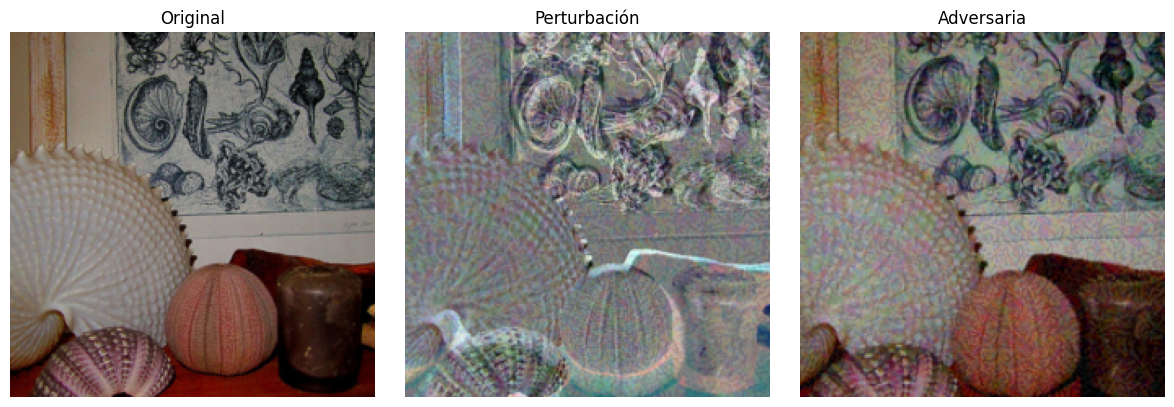

In [69]:
show_comparison(ORIGINAL[0][0], FGSM_005[0][0], save_fig=True, title="Comparativa FGSM")

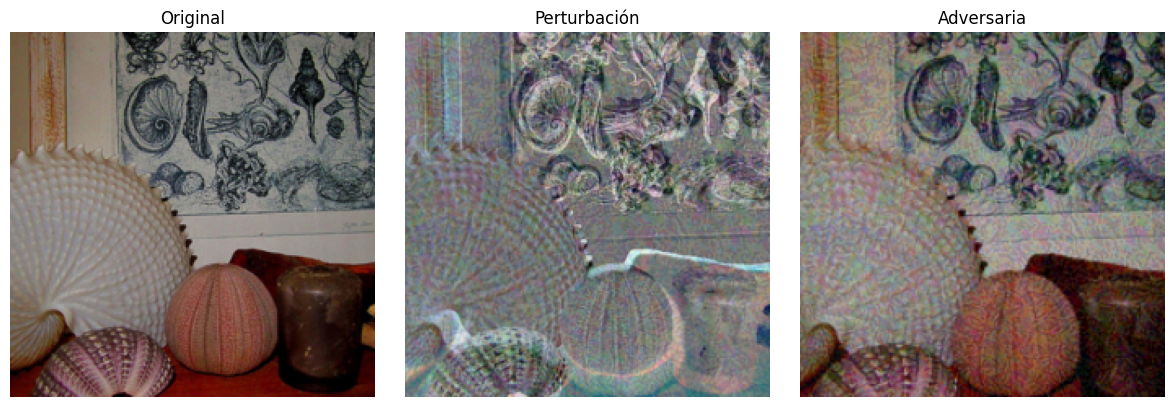

In [70]:
show_comparison(ORIGINAL[0][0], RFGSM_005[0][0], save_fig=True, title="Comparativa FGSM")

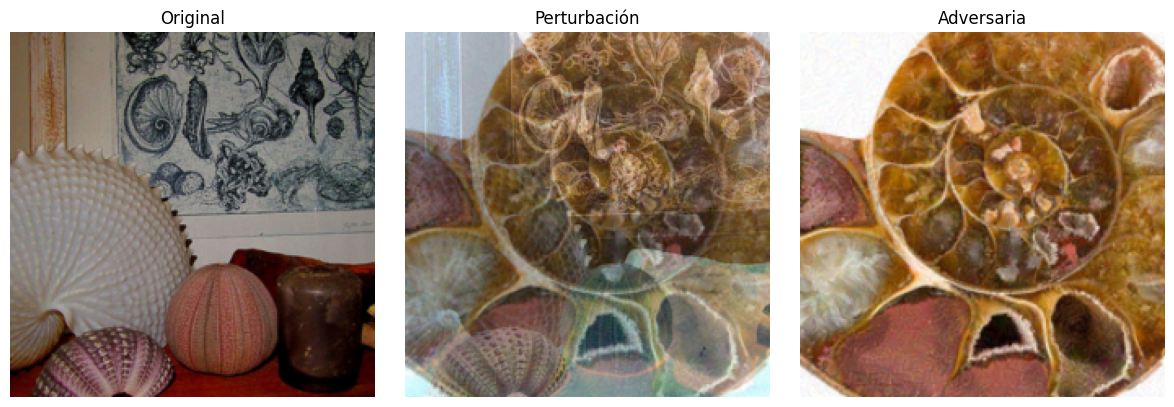

In [71]:
show_comparison(ORIGINAL[0][0], PGD_005[0][0], save_fig=True, title="Comparativa FGSM")